This notebook is exploratory. The goal is to experiment with charts to get an overview of the data and find more questions to base additional calculations off of. 

In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [35]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

In [36]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

In [37]:
df_country = pd.read_csv("../Data/country_ai_index.csv")

Initial testing brought me to the conclusion that correlation analysis would be valuable. The next few blocks explore overall dataset correlation. 

In [ ]:
# I want to merge country to company for broad correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [ ]:
# For the merge we did not get any null values -synthetic data is complete
ai_analysis.isnull().sum()

In [40]:
#This variable chooses and organizes columns for a massive correlation matrix
corr_df = ai_analysis[
    [
        # AI adoption 
        "ai_adoption_rate",
        "years_using_ai",
        "num_ai_tools_used",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_maturity_score",
        # Governance / risk
        "ai_failure_rate",
        "ai_risk_management_score",
        # Automation
        "task_automation_rate",
        # Business outcomes
        "productivity_change_percent",
        "revenue_growth_percent",
        "cost_reduction_percent",
        "innovation_score",
        "customer_satisfaction",
        # Workforce impact
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees",
        "num_employees",
        # Country factors
        "gdp_per_capita",
        "internet_penetration",
        "digital_maturity_index",
        "ai_patent_filings_2024",
        "ai_researchers_per_million"
    ]
]

In [ ]:
""""
The correlation matrix had a few interesting findings involving workforce changes, 
which drove the next stage of analysis
"""
corr_matrix = corr_df.corr()

corr_matrix

,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_risk_management_score,task_automation_rate,productivity_change_percent,...,customer_satisfaction,jobs_created,jobs_displaced,reskilled_employees,num_employees,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
ai_adoption_rate,1.000000,0.194012,0.539365,0.728420,0.744476,0.841339,-0.657283,0.371078,0.703631,0.674973,...,0.422141,0.305982,0.278499,0.268673,0.179024,0.084071,0.065313,0.065344,0.020530,0.066572
years_using_ai,0.194012,1.000000,0.118055,0.134539,0.138527,0.155064,-0.098316,0.065638,0.134012,0.116494,...,0.068908,0.038894,0.034030,0.034274,0.023035,0.017045,0.012622,0.014992,0.010896,0.014742
num_ai_tools_used,0.539365,0.118055,1.000000,0.393811,0.400556,0.454016,-0.351571,0.201708,0.379691,0.364423,...,0.226932,0.164251,0.150138,0.144899,0.095097,0.045352,0.034089,0.033821,0.011109,0.035215
ai_training_hours,0.728420,0.134539,0.393811,1.000000,0.560236,0.821696,-0.739570,0.365538,0.513259,0.633740,...,0.415638,0.301574,0.275714,0.344071,0.212653,0.058913,0.045288,0.044919,0.012355,0.046201
ai_budget_percentage,0.744476,0.138527,0.400556,0.560236,1.000000,0.819248,-0.527048,0.367073,0.517041,0.604105,...,0.368443,0.356931,0.327195,0.321456,0.271892,0.058674,0.045336,0.043950,0.011948,0.046661
ai_maturity_score,0.841339,0.155064,0.454016,0.821696,0.819248,1.000000,-0.697749,0.445840,0.590048,0.737314,...,0.458789,0.398065,0.364793,0.388040,0.298857,0.065990,0.050482,0.049445,0.013477,0.051881
ai_failure_rate,-0.657283,-0.098316,-0.351571,-0.739570,-0.527048,-0.697749,1.000000,-0.312925,-0.462539,-0.593667,...,-0.434765,-0.259982,-0.237706,-0.272529,-0.179474,-0.055131,-0.043751,-0.042467,-0.012411,-0.043397
ai_risk_management_score,0.371078,0.065638,0.201708,0.365538,0.367073,0.445840,-0.312925,1.000000,0.258595,0.328775,...,0.204855,0.207998,0.190840,0.202653,0.167333,0.026329,0.022883,0.018935,0.002168,0.019227
task_automation_rate,0.703631,0.134012,0.379691,0.513259,0.517041,0.590048,-0.462539,0.258595,1.000000,0.582721,...,0.345878,0.216635,0.286413,0.190246,0.126533,0.062197,0.049653,0.051581,0.019071,0.052065
productivity_change_percent,0.674973,0.116494,0.364423,0.633740,0.604105,0.737314,-0.593667,0.328775,0.582721,1.000000,...,0.569821,0.291897,0.287572,0.282751,0.207824,0.051191,0.039234,0.040381,0.014018,0.040627


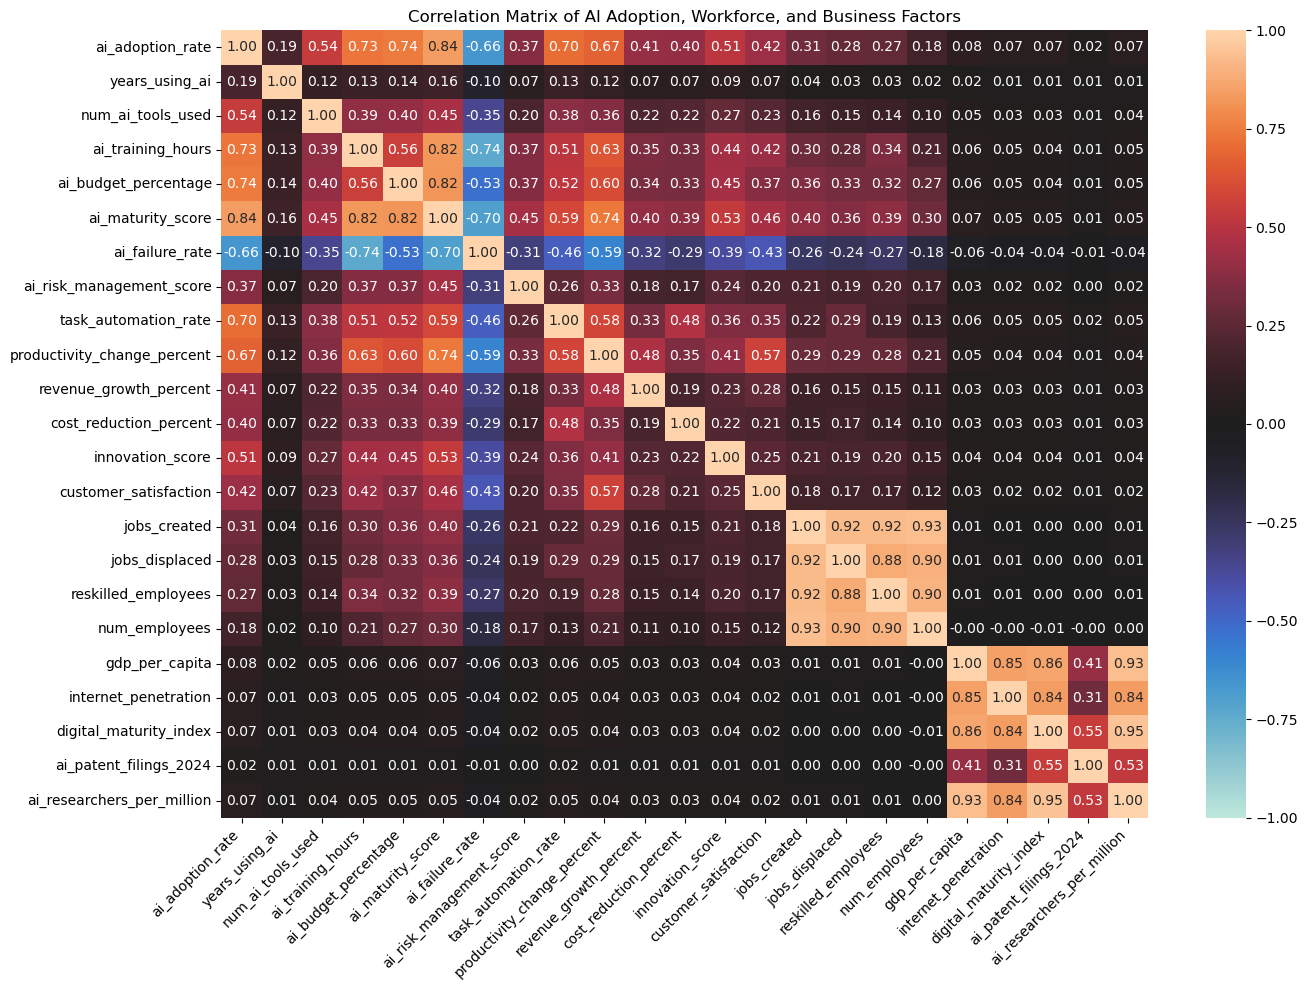

In [ ]:
#Plotting the matrix
#The matrix is large, but drew my attention to the workforce changes

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of AI Adoption, Workforce, and Business Factors")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [ ]:
# This flattens the correlation matrix and lets us grab just the strongest pairs
corr_pairs = (corr_matrix.unstack().reset_index())
# rename the columns
corr_pairs.columns = [ "Variable 1","Variable 2","Correlation"]
# don't count self correlation
corr_pairs = corr_pairs[corr_pairs["Variable 1"] != corr_pairs["Variable 2"]]

corr_pairs.sort_values("Correlation",ascending=False).head(10)

,Variable 1,Variable 2,Correlation
482,digital_maturity_index,ai_researchers_per_million,0.952405
526,ai_researchers_per_million,digital_maturity_index,0.952405
339,jobs_created,num_employees,0.932788
405,num_employees,jobs_created,0.932788
436,gdp_per_capita,ai_researchers_per_million,0.932110
524,ai_researchers_per_million,gdp_per_capita,0.932110
359,jobs_displaced,jobs_created,0.923838
337,jobs_created,jobs_displaced,0.923838
338,jobs_created,reskilled_employees,0.923788
382,reskilled_employees,jobs_created,0.923788


After evaluating the large correlation matrix, I found that investigating workforce changes like jobs created/ displaced and reskilled employees would prove interesting. To explore the job changes, I am going to use a new notebook.